In [18]:
# Descargando las dependencias 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn. datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split

In [2]:
# Cargando, creando y realizando una copia del DataFrame

california = fetch_california_housing(as_frame=True)
df = california.frame
df_copy = df.copy()
df_copy.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [15]:
# Verificando su shape

df_copy.shape

(20640, 9)

In [ ]:
# Verificando si el dataset tiene valores nulos, por columnas

df_copy.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [20]:
# Verificando si el dataset tiene valores nulos, en su conjunto

df_copy.isnull().values.any()

np.False_

In [16]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [21]:
df_copy.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


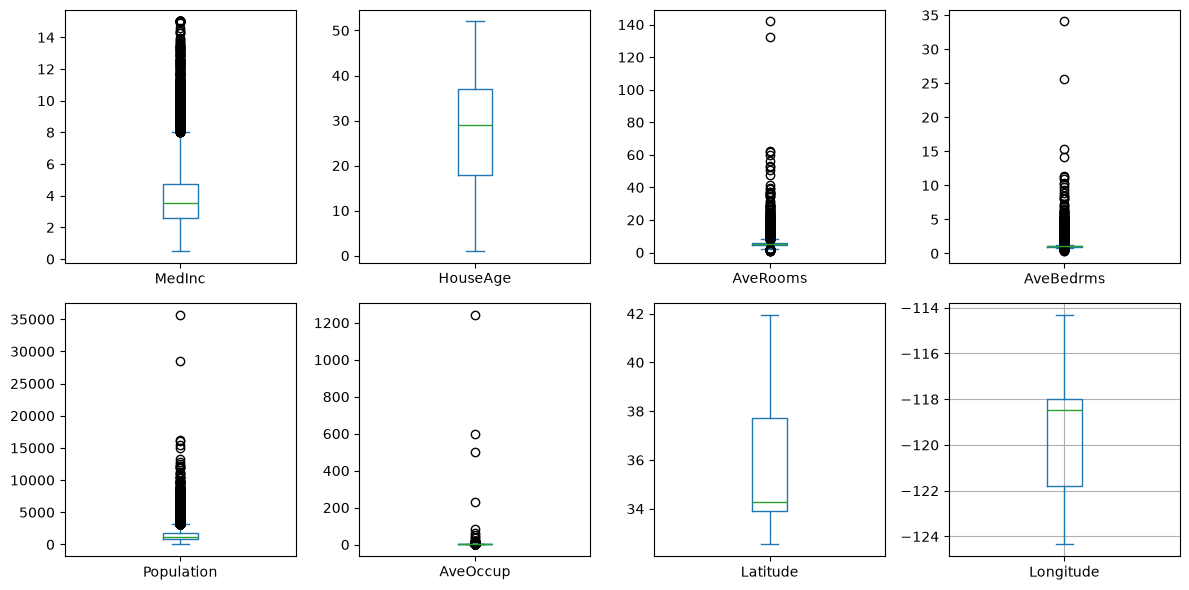

In [ ]:
# Graficando un boxplot a todas las variavles nuemricas, para visualizar los datos átipicos

df_numericas = df_copy.drop(columns=["MedHouseVal"]).select_dtypes(include=['int64', 'float64'])
df_numericas.plot(kind='box', subplots=True, layout=(2, 4), figsize=(12, 6))
plt.tight_layout()
plt.show()

In [3]:
# Separando los datos, en variables de entrada y salida
x = df_copy.drop(columns=["MedHouseVal"])
y = df_copy["MedHouseVal"].copy()

# Separando los datos, en entrenamiento, testeo y validación
x_train, x_mod, y_train, y_mod = train_test_split(x , y, test_size=0.2, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_mod, y_mod, test_size=0.5, random_state=42)

In [14]:
# Definiendo el estimador
rf = RandomForestRegressor(random_state=42)

# Definiendo la grilla de los valores e hiperpárametros
param_grid = [
    {
        "n_estimators": [100, 150, 175, 200, 250],
        "max_depth": [10, 15, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", 0.7],
        "bootstrap" : [True],
        "max_samples": [0.8]
    }
]

# Definiendo el método de busqueda de estos valores óptimos
grid_search = GridSearchCV(
    estimator= rf,
    param_grid= param_grid,
    cv= 5,
    scoring="neg_mean_absolute_error",
    n_jobs= -1,
    verbose= 1
)

In [15]:
# Realizando la busqueda de los valores óptimos
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'bootstrap': [True], 'max_depth': [10, 15, ...], 'max_features': ['sqrt', 0.7], 'max_samples': [0.8], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto

In [ ]:
# Los mejores parámetros encontrados
print(f"Los mejores parámetros encontrados: {grid_search.best_params_}")

# El mejor resultado que alcanzo
print(f"El mejor resultado que alcanzo: {grid_search.best_score_}")



Los mejores parámetros encontrados: {'bootstrap': True, 'max_depth': 20, 'max_features': 0.7, 'max_samples': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}
El mejor resultado que alcanzo: -0.33354481998824703


In [17]:
# Asignanado a una variable el mejor estimador encontrado 
best_estimator = grid_search.best_estimator_

In [22]:
# La importancia de cada característica a la hora construir el estimador
print(f"El peso de cada característica: {best_estimator.feature_importances_}")

El peso de cada característica: [0.46332211 0.0557073  0.08642578 0.03504906 0.03014556 0.13347574
 0.09908229 0.09679217]


In [19]:
# Realisando una predicción con el sub conjunto de testeo
y_pred_test = best_estimator.predict(x_test)

# Realisando una predicción con el sub conjunto de validación
y_pred_val = best_estimator.predict(x_val)

In [20]:
# Calculando MAE y R2
r2_test = r2_score(y_test, y_pred_test)
r2_val = r2_score(y_val, y_pred_val)
mae_test = mean_absolute_error(y_test, y_pred_test)
mae_val = mean_absolute_error(y_val, y_pred_val)

# Mostrando por consola los resultados obtenidos
print(f"testeo, r2: {r2_test}, MAE: {mae_test}")
print(f"validación, r2: {r2_val}, MAE: {mae_val}")

testeo, r2: 0.8115739008718648, MAE: 0.3252362475397635
validación, r2: 0.8021642271453014, MAE: 0.3285230110347151
